In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_model_summary
import numpy as np
import IGC
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

torch.cuda.empty_cache()
nsteps = 10 # number of time steps
M=10 # number of signals
conns_list=[5]
nrs=0
np.random.seed(100)
rind=np.random.rand(M).argsort()
conns=[]
receivers=[1,2,3,4,5]
for i, rec in enumerate(receivers):
    conns.append([int(rind[i]), int(rind[-rec])])
n_conns=len(conns)
conns=np.array(conns)
print(conns.T)

rel_unrel=np.zeros(M)
rel_unrel[conns[:,1]]=1
con_rel=np.argwhere(rel_unrel>0).squeeze()
con_unrel=np.argwhere(rel_unrel==0).squeeze()
print(f'Total available number of connectivities: {n_conns}')
print(f'Predictable signals: {con_rel}')
print(f'Unpredictable signals: {con_unrel}')
hidden_size=[100,100]

org_con=torch.zeros([M, M])
org_con[conns[:,1],conns[:,0]]=1

[[4 5 8 1 2]
 [3 7 6 9 0]]
Total available number of connectivities: 5
Predictable signals: [0 3 6 7 9]
Unpredictable signals: [1 2 4 5 8]


In [4]:
device='cuda:0'

class MVAR_DMA(nn.Module):
    """ 
    Regression with a multihead attention model
    """
    def __init__(self, input_size, hidden_size, seq_len, num_layers=1):
        super(MVAR_DMA, self).__init__()
        self.seq_len = seq_len
        self.hidden_size = hidden_size
        self.lstm1 = IGC.DM_LSTM(input_size, hidden_size[0], seq_len, num_layers, bidirectional=True)
        # Attention layer
        self.attention_layer = nn.Linear(hidden_size[0]*2, hidden_size[0]*2)
        # Feedforward network
        self.fc1 = nn.Linear(hidden_size[0]*2, hidden_size[1])
        self.fc2 = nn.Linear(hidden_size[1], input_size)
        
    def forward(self, x):
        out          = self.lstm1(x)
        out          = F.tanh(out)
        # Apply attention to each hidden state
        attn_weights = torch.softmax(self.attention_layer(out), dim=1)  # Shape: (batch_size, seq_len, 1)
        weighted_mem = out * attn_weights  # Shape: (batch_size, seq_len, hidden_dim)
        # Aggregate the weighted hidden states
        out          = weighted_mem.sum(dim=1)  # Shape: (batch_size, hidden_dim)
       # Apply layer normalization and feedforward network
        out          = F.tanh(self.fc1(out))
        out          = self.fc2(out)
        
        return out

hidden_size=[50, 50]
model_dma = MVAR_DMA(M+nrs, hidden_size, nsteps, 1).to(device)
print('Model summary (DM+Attention)')
print(pytorch_model_summary.summary(model_dma, torch.zeros(1,nsteps,M+nrs).to(device), max_depth=None, show_input=True))

Model summary (DM+Attention)
---------------------------------------------------------------------------------
      Layer (type)                   Input Shape         Param #     Tr. Param #
        LSTMCell-1     [1, 10], [1, 50], [1, 50]          12,400          12,400
        LSTMCell-2     [1, 10], [1, 50], [1, 50]          12,400          12,400
          Linear-3                  [1, 10, 100]          10,100          10,100
          Linear-4                      [1, 100]           5,050           5,050
          Linear-5                       [1, 50]             510             510
Total params: 40,460
Trainable params: 40,460
Non-trainable params: 0
---------------------------------------------------------------------------------


.......Early termination (Total elapsed time: 12.363s)
....IGC computation time: 0.277s
00000000000000000000000000000000000000000000000000000000000000000000000000000000
* Number of connectivities: 5 *
00000000000000000000000000000000000000000000000000000000000000000000000000000000
Variables that can be predictable
	DM+Attn       : 0.981
Variables that cannot be predictable
	DM+Attn       : 0.024
Weight similarity:
* Weight length: 10
Total correlation: DM+Attn
                  0.953


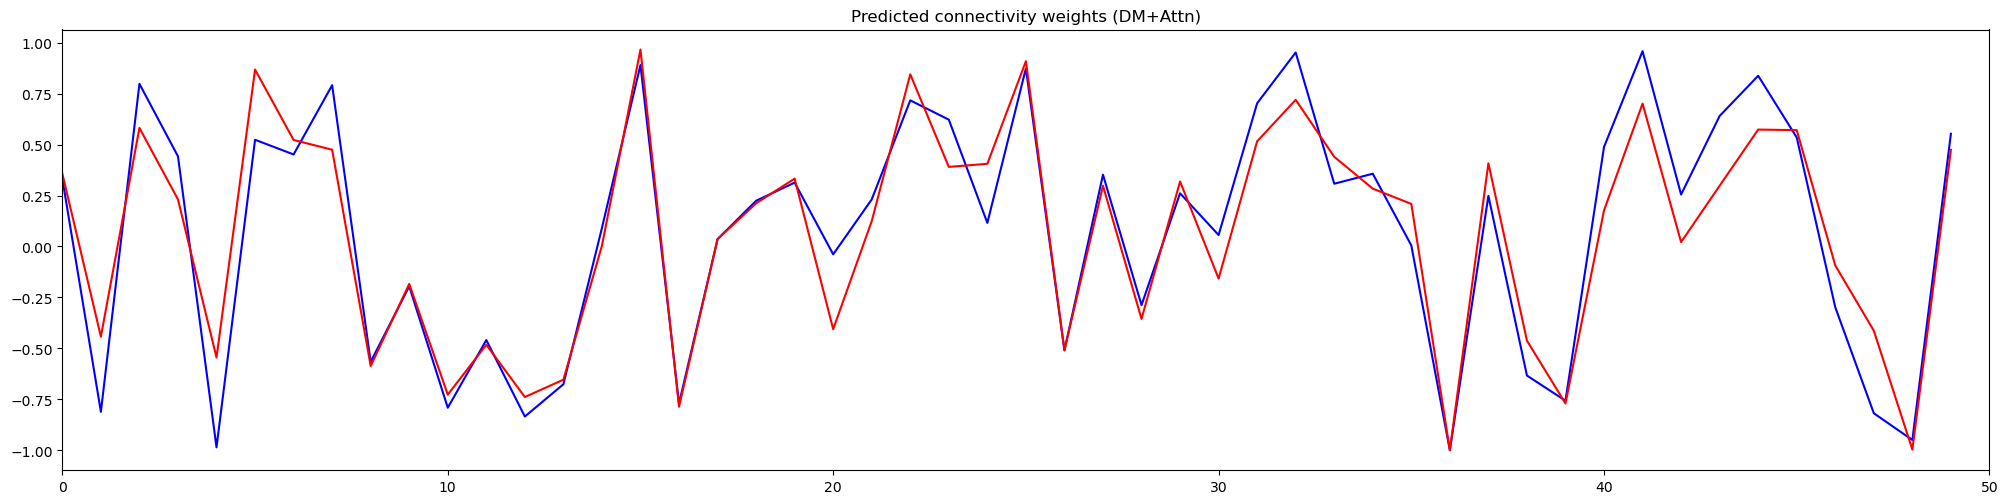

AUC:
	DM+Attn       : 0.998
DM+Attn        : 1.000, 1.000, 1.000, 1.000


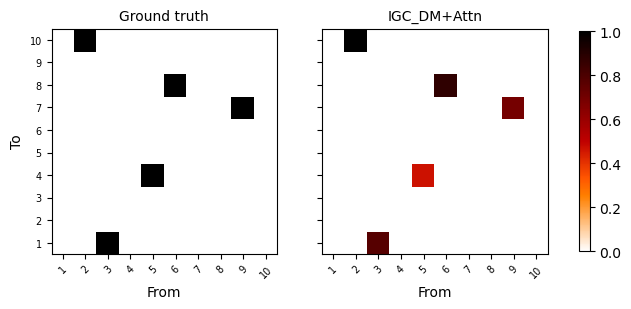

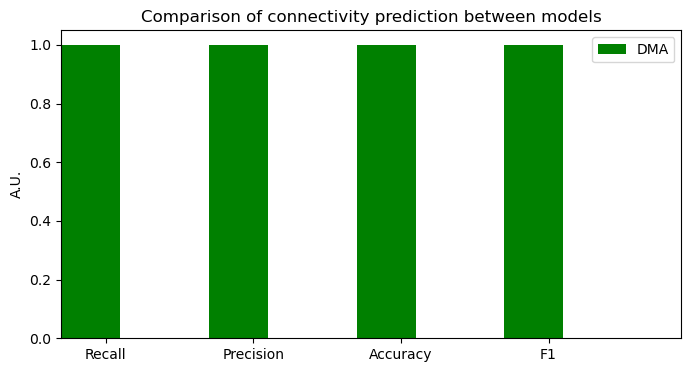

In [19]:
results=[]
"""
Signal generation
"""
inc_conns=conns[:n_conns,:]
rel_unrel=np.zeros(M)
rel_unrel[inc_conns[:,1]]=1
con_rel=np.argwhere(rel_unrel>0).squeeze()
con_unrel=np.argwhere(rel_unrel==0).squeeze()
org_con=torch.zeros([M, M])
org_con[inc_conns[:,1],inc_conns[:,0]]=1

x, weights = IGC.simulate_data_random(M, inc_conns, 0.2, order=nsteps, nonlinear=False, fixed_weight=False, sn=10000)
# Add random signals for statistical inference
x = torch.cat([x, torch.randn(x.shape[0], nrs)], axis=1)
# Normalization of input data
for i in range(x.shape[1]):
    x[:,i]=(x[:,i]-torch.mean(x[:,i]))/torch.std(x[:,i])/3.0
# Reconstruction of a dataset with (order) time steps
x_train, y_train = IGC.multivariate_data(x, x, 0, int(x.shape[0]*0.8), nsteps, 1, 1, True)
x_test, y_test = IGC.multivariate_data(x, x, int(x.shape[0]*0.8), int(x.shape[0]), nsteps, 1, 1, True)
x_train = x_train.float()
y_train = y_train.float()
x_test = x_test.float()
y_test = y_test.float()
total_weights=torch.zeros(0)
for i in range(len(weights)):
    total_weights=torch.cat((total_weights, weights[i].flip(0)))
"""
Ensemble prediction (5 repetition)
"""
n_ensembles=1
igc_bundle=torch.zeros([n_ensembles,M,M])
weight_bundle=torch.zeros([n_ensembles, nsteps, M+nrs, M+nrs])
ensemble_cor_tot=torch.zeros(1)
ensemble_cor=torch.zeros([M+nrs])
ensemble_y=torch.zeros([y_test.shape[0],y_test.shape[1]])
for en in range(n_ensembles):
    """
    Define models
    """
    model_dma = MVAR_DMA(M+nrs, hidden_size, nsteps, 1).to(device)
    """
    Train models
    """
    trainhist, testhist = IGC.train_model(model_dma, (x_train, y_train), (x_test, y_test), 
                                          50, n_batch=100, verbose=False, device=device)
    # Evaluate regression performance at each output
    ensemble_y += IGC.evaluate_testset(model_dma, (x_test, y_test), nbatch=128)
    """
    Compute gradients
    """
    igc = IGC.ig_connectivity(x, model=model_dma, order=nsteps, nrs=nrs, stat='pdc', device=device)
    weight_bundle[en, :, :, :] = igc[5]
    igc_bundle[en, :, :] = igc[2]
"""
Compute correlation coefficient between predicted and real y_tests
"""
ensemble_y /= n_ensembles
for i in range(y_test.shape[-1]):
    ensemble_cor[i]=torch.corrcoef(torch.stack([ensemble_y[:,i], y_test[:,i]]))[0,1]
ensemble_cor_tot=torch.corrcoef(torch.stack([ensemble_y.reshape(-1), 
                                             y_test.reshape(-1)]))[0,1]
igc_bundle=igc_bundle.mean(0)
weight_bundle=weight_bundle.mean(0)

model_name='DM+Attn'
print(f'{0:080d}')
print(f'* Number of connectivities: {inc_conns.shape[0]} *')
print(f'{0:080d}')
print('Variables that can be predictable')
print(f'\t{model_name:14s}: {ensemble_cor[con_rel].abs().mean():5.3f}')
print('Variables that cannot be predictable')
print(f'\t{model_name:14s}: {ensemble_cor[con_unrel].abs().mean():5.3f}')
"""
Evaluate estimated weights
"""
print('Weight similarity:')
corr = torch.zeros([inc_conns.shape[0]])
pred_weights=torch.zeros(0)
pred_w=torch.zeros(0)
for i in range(inc_conns.shape[0]):
    corr[i]=torch.corrcoef(torch.stack((weight_bundle[:,inc_conns[i,1],inc_conns[i,0]],weights[i].flip(0)),dim=1).T)[0,1]
    pred_w=torch.cat((pred_w, weight_bundle[:,inc_conns[i,1],inc_conns[i,0]]))
pred_weights=pred_w
print(f'* Weight length: {nsteps}')
print('Total correlation: DM+Attn')
print('                  {:5.3f}'.format(corr.mean()))
#print('Total correlation')
# Display predicted weights
fig, ax = plt.subplots(1, 1, sharex=True, figsize=(20,5))
fig.tight_layout()
ax.plot(total_weights/total_weights.abs().max(), 'b', label='Weights')
ax.plot(pred_weights/pred_weights.abs().max(), color='r', label=model_name)
ax.set_xlim(0,nsteps*inc_conns.shape[0])
ax.set_title(f'Predicted connectivity weights ({model_name})')
plt.show()
"""
Connectivity evaluation
"""
print('AUC:')
fpr, tpr, thresh = roc_curve(org_con.flatten(), igc_bundle.flatten(), pos_label=1)
auc_value=auc(fpr, tpr)
print(f'\t{model_name:14s}: {auc_value:5.3f}')
"""
Evaluate prediction metrics
"""
# Display connectivity results
# Scale connectivity
sig_con=0.2
con_res = torch.diagonal_scatter(igc_bundle, torch.zeros(igc_bundle.shape[0]), 0)
thr_con = F.threshold(con_res, sig_con, 0)
thr_con = thr_con/thr_con.max()
con_eval=IGC.evaluate_connectivity_with_hitmap(thr_con, org_con)
print(f'{model_name:15s}: {con_eval['recall']:5.3f}, {con_eval['precision']:5.3f}, {con_eval['accuracy']:5.3f}, {con_eval['F1']:5.3f}')
# Scale connectivity
IGC.display_connectivity((org_con, thr_con), 
                         title=['Ground truth', 'IGC_DM+Attn'])
plt.figure(figsize=(8,4))
bar_width=0.4
bar_x=np.arange(4)
plt.bar(bar_x+bar_width*0, con_eval.values(), bar_width, color='green', label='DMA')
plt.xlim(-0.2,4.0)
plt.title('Comparison of connectivity prediction between models')
plt.ylabel('A.U.')
plt.xticks(bar_x+0.1, ['Recall', 'Precision', 'Accuracy', 'F1'])
plt.legend()
plt.show()